In [26]:
import numpy as np 
import matplotlib.pyplot as plt 
import os

print(os.getcwd())

c:\Users\amlat\Desktop\Ingénieur\OpenFoam\Lid-driven_cavity


In [27]:
tps = ["0005","001","0015"]

### CFL

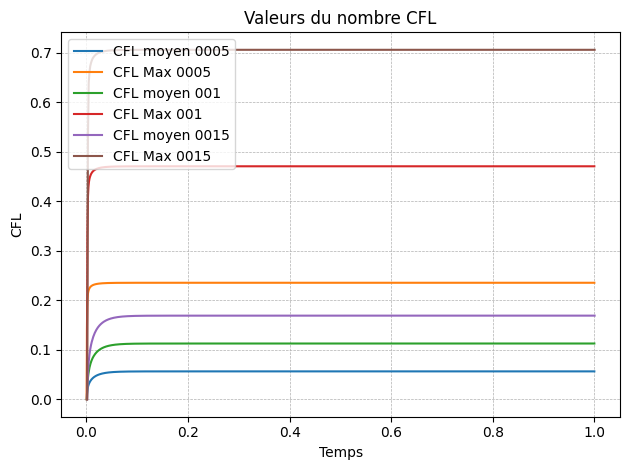

In [28]:
time_max = []
time_mean = []
CFL_max = []
CFL_mean = []

for k in tps:
    a = []
    b = []
    with open("Tps_"+k+"/logs/CourantMax_0", "r") as f:
        for line in f:
            parts = line.split()
            a.append(float(parts[0]))
            b.append(float(parts[1]))
    time_max.append(a)
    CFL_max.append(b)
   

for k in tps:
    a = []
    b = []
    with open("Tps_"+k+"/logs/CourantMean_0", "r") as f:
        for line in f:
            parts = line.split()
            a.append(float(parts[0]))
            b.append(float(parts[1]))
    time_mean.append(a)
    CFL_mean.append(b)
       

#plt.yscale("log")
i = 0
for k in tps:
    plt.plot(time_mean[i],CFL_mean[i],label="CFL moyen "+k)
    plt.plot(time_max[i],CFL_max[i],label="CFL Max "+k)
    i+=1

plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.xlabel("Temps")
plt.ylabel("CFL")
plt.title("Valeurs du nombre CFL")
plt.legend()
plt.tight_layout()
plt.show()

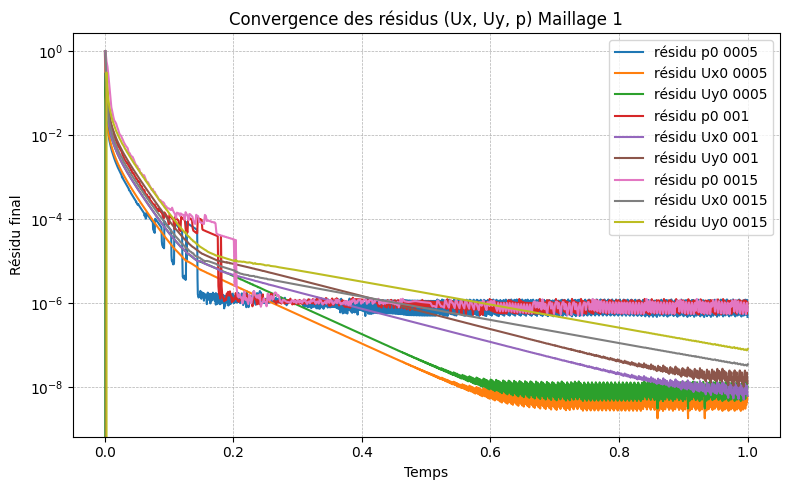

In [29]:
x = []
y = []

time_p0 = []
p0 = []
time_Ux0 = []
Ux0 = []
time_Uy0 = []
Uy0 = []

# Récupération de p0
for k in tps:
    a = []
    b = []
    with open("Tps_"+k+"/logs/p_0", "r") as f:
        for line in f:
            parts = line.split()
            a.append(float(parts[0]))
            b.append(float(parts[1]))
    time_p0.append(a)
    p0.append(b)
   
# Récupération de Ux 
for k in tps:
    a = []
    b = []
    with open("Tps_"+k+"/logs/Ux_0", "r") as f:
        for line in f:
            parts = line.split()
            a.append(float(parts[0]))
            b.append(float(parts[1]))
    time_Ux0.append(a)
    Ux0.append(b)

# Récupération de Uy
for k in tps:
    a = []
    b = []
    with open("Tps_"+k+"/logs/Uy_0", "r") as f:
        for line in f:
            parts = line.split()
            a.append(float(parts[0]))
            b.append(float(parts[1]))
    time_Uy0.append(a)
    Uy0.append(b)


# Plot
plt.figure(figsize=(8,5))
i = 0
for k in tps:
    plt.plot(time_p0[i],p0[i],label="résidu p0 "+k)
    plt.plot(time_Ux0[i],Ux0[i],label="résidu Ux0 "+k)
    plt.plot(time_Uy0[i],Uy0[i],label="résidu Uy0 "+k)
    i+=1

plt.yscale("log")
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.xlabel("Temps")
plt.ylabel("Résidu final")
plt.title("Convergence des résidus (Ux, Uy, p) Maillage 1")
plt.legend()
plt.tight_layout()
plt.show()

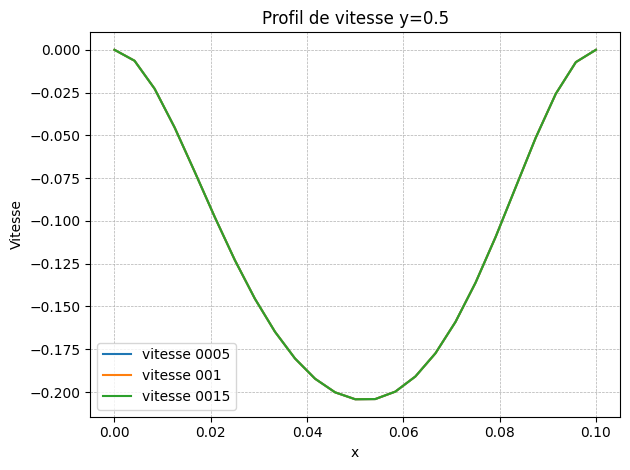

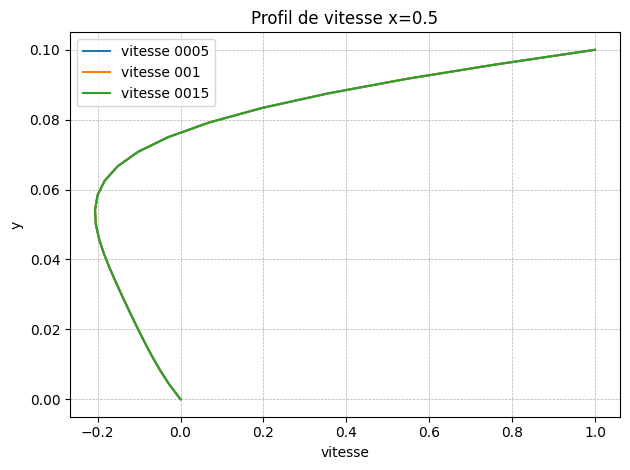

In [30]:
x = []
vitesse_x = []

# y = 0.5
for k in tps:
    a = []
    b = []
    c = []
    d = []
    e = []
    with open(f"Tps_{k}/postProcessing/sampleUx/{max((d for d in os.listdir(f'Tps_{k}/postProcessing/sampleUx') if d.replace('.', '', 1).isdigit()), key=float)}/line1_U.xy", "r") as f:
        for line in f:
            parts = line.split()
            a.append(float(parts[0]))
            b.append(float(parts[1]))
            c.append(float(parts[2]))
            d.append(float(parts[3]))
    for i in range(len(a)):
        e.append(np.sqrt(b[i]**2+c[i]**2+d[i]**2))
    x.append(a)
    vitesse_x.append(b)

i = 0
for k in tps:
    plt.plot(x[i],vitesse_x[i],label="vitesse "+k)
    i+=1
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.xlabel("x")
plt.ylabel("Vitesse")
plt.title("Profil de vitesse y=0.5")
plt.legend()
plt.tight_layout()
plt.show()




y = []
vitesse_y = []

# x = 0.5
for k in tps:
    a = []
    b = []
    c = []
    d = []
    e = []
    with open(f"Tps_{k}/postProcessing/sampleUy/{max((d for d in os.listdir(f'Tps_{k}/postProcessing/sampleUx') if d.replace('.', '', 1).isdigit()), key=float)}/line1_U.xy", "r") as f:
        for line in f:
            parts = line.split()
            a.append(float(parts[0]))
            b.append(float(parts[1]))
            c.append(float(parts[2]))
            d.append(float(parts[3]))
    for i in range(len(a)):
        e.append(np.sqrt(b[i]**2+c[i]**2+d[i]**2))
    y.append(a)
    vitesse_y.append(b)

i = 0
for k in tps:
    plt.plot(vitesse_y[i],y[i],label="vitesse "+k)
    i+=1
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.xlabel("vitesse")
plt.ylabel("y")
plt.title("Profil de vitesse x=0.5")
plt.legend()
plt.tight_layout()
plt.show()
